In [1]:
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import os
import pandas as pd

In [2]:
exp_dir = "/home/chanb/scratch/code/unsupervised_rl/HILP/hilp_zsrl/exp_local/EXP"
exp_names = os.listdir(exp_dir)

Mfb_ddpg_icm_apt 50.47825659133901
Msf_icm_apt 20.99582569023859
Mfb_ddpg_random 1.9082008885727243e-254
Mfb_ddpg_rnd 2.953485970063868e-253
Mfb_ddpg_proto 4.804606146649062e-164
Msf_random 1.229463093028079e-223
Msf_proto 9.344225008905812e-267
Msf_rnd 2.342340555829655e-179


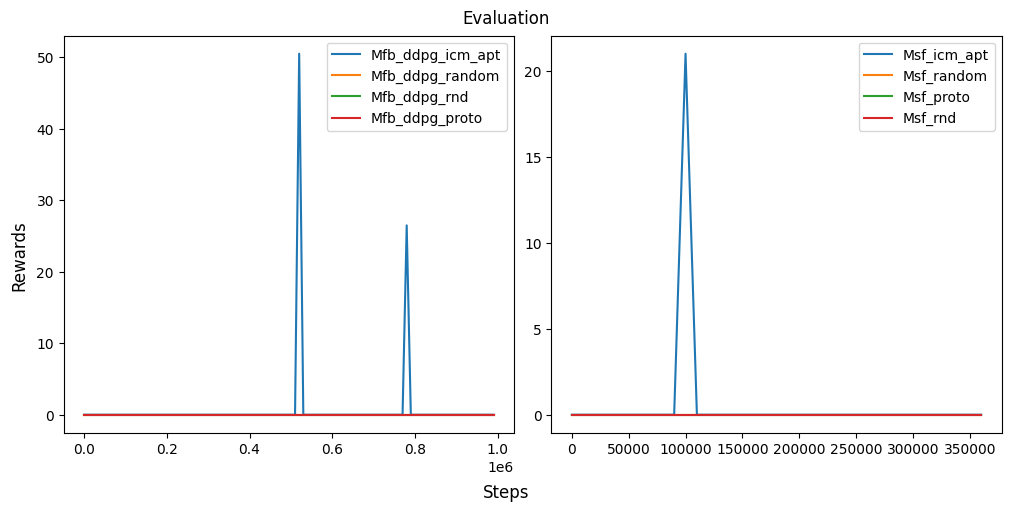

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout="constrained")

for exp_name in exp_names:
    curr_dirpath = os.path.join(exp_dir, exp_name)
    key = exp_name.split(".")[-1]
    df = pd.read_csv(os.path.join(curr_dirpath, "eval.csv"))

    if key.startswith("Mfb"):
        ax = axes[0]
    else:
        ax = axes[1]

    ax.plot(
        df["step"],
        df["episode_reward"],
        label=key,
    )
    print(key, df["episode_reward"].max())

for ax in axes:
    ax.legend()
fig.suptitle("Evaluation")
fig.supxlabel("Steps")
fig.supylabel("Rewards")
plt.show()

In [4]:
import numpy as np
import omegaconf as omgcf
import torch

from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from url_benchmark.train_offline import Workspace

  from scipy.ndimage.filters import sobel

The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path='.', config_name='base_config')



In [5]:
exp_dir = "/home/chanb/scratch/code/unsupervised_rl/HILP/hilp_zsrl/exp_local/EXP"
exp_names = os.listdir(exp_dir)
exp_names

['sd0.4950186.0.20260513102351.Epoint_mass_maze_reach_bottom_right.Mfb_ddpg_icm_apt',
 'sd0.4950186.0.20260513102351.Epoint_mass_maze_reach_bottom_right.Msf_icm_apt',
 'sd0.4950186.0.20260513102351.Epoint_mass_maze_reach_bottom_right.Mfb_ddpg_random',
 'sd0.4950186.0.20260513102351.Epoint_mass_maze_reach_bottom_right.Mfb_ddpg_rnd',
 'sd0.4920602.0.20260512042840.Epoint_mass_maze_reach_bottom_right.Mfb_ddpg_proto',
 'sd0.4950186.0.20260513102351.Epoint_mass_maze_reach_bottom_right.Msf_random',
 'sd0.4950186.0.20260513102351.Epoint_mass_maze_reach_bottom_right.Msf_proto',
 'sd0.4950186.0.20260513102351.Epoint_mass_maze_reach_bottom_right.Msf_rnd']

In [6]:
curr_dirpath = os.path.join(exp_dir, exp_names[0])

In [7]:
config_path = os.path.join(curr_dirpath, ".hydra", "config.yaml")
model_path = os.path.join(curr_dirpath, "models", "latest.pt")

In [8]:
cfg = omgcf.OmegaConf.load(config_path)
cfg.use_wandb = False

In [9]:
workspace = Workspace(cfg)

Workspace: /scratch/chanb/code/unsupervised_rl/HILP/hilp_zsrl
Running code in : /scratch/chanb/code/unsupervised_rl/HILP/hilp_zsrl/url_benchmark


  warnings.warn("Can't initialize NVML")



replay dir: /scratch/chanb/datasets/point/icm_apt/buffer
loading Replay from %s /home/chanb/scratch/datasets/unsupervised_rl/datasets/point_mass_maze/icm_apt/replay.pt
loading checkpoint from /home/chanb/scratch/datasets/unsupervised_rl/datasets/point_mass_maze/icm_apt/replay.pt


In [10]:
batch_size = 100

batch = workspace.replay_loader.sample(batch_size)
sampled_z = workspace.agent.sample_z(1)
sampled_z = torch.tile(sampled_z, (batch_size, 1))

In [11]:
if hasattr(workspace.agent, "forward_net"):
    f1, f2 = workspace.agent.forward_net(torch.tensor(batch.obs), sampled_z, torch.tensor(batch.action))
else:
    f1, f2 = workspace.agent.successor_net(torch.tensor(batch.obs), sampled_z, torch.tensor(batch.action))

In [12]:
# pca = PCA(n_components=2)
# d1 = pca.fit_transform(f1.detach().numpy())

tsne = TSNE(n_components=3)
d1 = tsne.fit_transform(f1.detach().numpy())

In [13]:
sorted_idxes = np.argsort(batch.obs[:, 0])

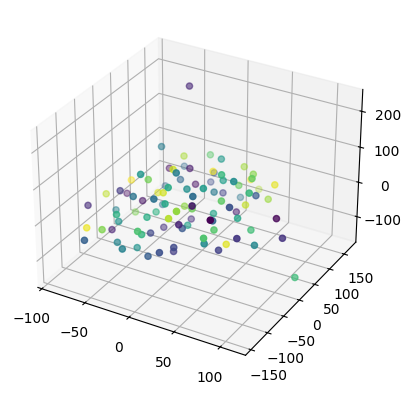

In [16]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(d1[:, 0][sorted_idxes], d1[:, 1][sorted_idxes], d1[:, 2][sorted_idxes], c=np.arange(batch_size))

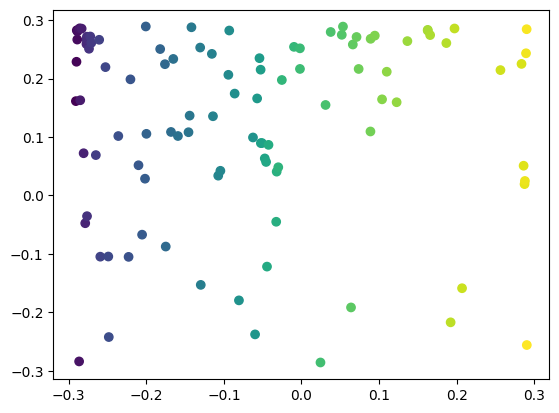

In [17]:
plt.scatter(batch.obs[:, 0][sorted_idxes], batch.obs[:, 1][sorted_idxes], c=np.arange(batch_size))